# Coming from sncosmo

If you fit SALT2 lightcurves with `sncosmo.fit_lc`, this page shows how to do the same fit with
{func}`saltjax.fit_salt`: how to convert your astropy tables, how the arguments translate, how
the results compare, and how to get an `sncosmo.Model` back to plot the fit.

:::{note}
This page assumes you know `sncosmo.fit_lc` and the SALT2 parameters (`t0`, `x0`, `x1`, `c`).
:::

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sncosmo
from astropy.table import Table
from astropy.cosmology import Planck18

import saltjax

PARAMS = ["t0", "x0", "x1", "c"]
pd.set_option("display.float_format", "{:.6g}".format)
warnings.filterwarnings("ignore", message="Assigned errors must be positive")  # iminuit, inside sncosmo

## The sncosmo way

sncosmo ships an example lightcurve: an astropy `Table` with `time`, `band`, `flux`, `fluxerr`,
`zp` and `zpsys` columns, and the redshift in its `meta`.

In [2]:
lc = sncosmo.load_example_data()
print(lc.meta)
lc[:5]

OrderedDict({'x1': 0.5, 'c': 0.2, 'z': 0.5, 'x0': 1.20482820761e-05, 't0': 55100.0})


time,band,flux,fluxerr,zp,zpsys
float64,str5,float64,float64,float64,str2
55070.0,sdssg,0.36351153597,0.672843847541,25.0,ab
55072.0512821,sdssr,-0.200801295864,0.672843847541,25.0,ab
55074.1025641,sdssi,0.307494232981,0.672843847541,25.0,ab
55076.1538462,sdssz,1.08776103656,0.672843847541,25.0,ab
55078.2051282,sdssg,-0.43667895645,0.672843847541,25.0,ab


We fit it with SALT2 plus Milky Way dust (CCM89, observer frame), with a Milky Way
$E(B-V) = 0.05$ mag that we assume known, and with the model covariance.

In [3]:
MWEBV = 0.05
model = sncosmo.Model(source="salt2", effects=[sncosmo.CCM89Dust()],
                      effect_names=["mw"], effect_frames=["obs"])
model.set(z=lc.meta["z"], mwebv=MWEBV)

t_start = time.perf_counter()
res, fitted_model = sncosmo.fit_lc(lc, model, ["t0", "x0", "x1", "c"], modelcov=True)
print(f"sncosmo.fit_lc: {time.perf_counter() - t_start:.2f} s, "
      f"chi2 = {res.chisq:.2f} for {res.ndof} dof, {res.nfit} fits")
pd.DataFrame({"value": [fitted_model.get(p) for p in PARAMS],
              "error": [res.errors[p] for p in PARAMS]}, index=PARAMS)

sncosmo.fit_lc: 0.11 s, chi2 = 33.19 for 36 dof, 2 fits


,value,error
t0,55100.4,0.410726
x0,1.31571e-05,5.15128e-07
x1,0.619902,0.359564
c,0.195884,0.0360871


## The same fit with saltjax

saltjax works on *many* lightcurves at once, stored in two pandas DataFrames:

- `data`: all the lightcurve points, with a `(target, observation)` MultiIndex and the
  columns `time` (or `mjd`, `jd`), `band`, `flux`, `fluxerr`, `zp` and optionally `zpsys`;
- `targets`: one row per target, with its redshift `z` and, optionally, the Milky Way
  E(B-V) in a `mwebv` column.

Here is a small helper that turns a list of sncosmo-style tables (with `meta['z']` and,
optionally, `meta['mwebv']`) into these two DataFrames. Reuse it with your own tables.

In [4]:
def tables_to_saltjax(tables, names=None):
    # (data, targets) DataFrames for saltjax.fit_salt from sncosmo-style tables
    names = list(range(len(tables)) if names is None else names)
    data = pd.concat({name: table.to_pandas() for name, table in zip(names, tables)},
                     names=["target", "obs"])
    targets = pd.DataFrame({"z": [table.meta["z"] for table in tables],
                            "mwebv": [table.meta.get("mwebv", 0.) for table in tables]},
                           index=pd.Index(names, name="target"))
    return data, targets

In [5]:
lc.meta["mwebv"] = MWEBV
data, targets = tables_to_saltjax([lc])
data.head()

time   band      flux  fluxerr  zp zpsys
target obs                                            
0      0     55070  sdssg  0.363512 0.672844  25    ab
       1   55072.1  sdssr -0.200801 0.672844  25    ab
       2   55074.1  sdssi  0.307494 0.672844  25    ab
       3   55076.2  sdssz   1.08776 0.672844  25    ab
       4   55078.2  sdssg -0.436679 0.672844  25    ab

In [6]:
targets

,z,mwebv
target,,
0,0.5,0.05


:::{important}
`phase_range` does not mean the same thing in both packages. In `sncosmo.fit_lc` the phase
is computed from the *fitted* t0 (the cut is updated while fitting); in {func}`saltjax.fit_salt`
it is computed once, from a **known** `t0` column of `targets`. Its default is `[-10, 40]`,
which requires that column. With real data, where t0 is what you fit, use `phase_range=None`
(all points, as `sncosmo.fit_lc` by default), or a preliminary t0 (e.g. from a first
saltjax fit) in `targets["t0"]`.
:::

Note also that `modelcov` is `True` by default in saltjax (`False` in sncosmo).

In [7]:
t_start = time.perf_counter()
result = saltjax.fit_salt(data, targets, modelcov=True, phase_range=None)
print(f"saltjax.fit_salt: {time.perf_counter() - t_start:.2f} s (first call: includes tabulation and compilation)")
result[["t0", "x0", "x1", "c", "t0_err", "x0_err", "x1_err", "c_err", "chi2", "ndof", "converged"]]

saltjax.fit_salt: 3.46 s (first call: includes tabulation and compilation)


,t0,x0,x1,c,t0_err,x0_err,x1_err,c_err,chi2,ndof,converged
target,,,,,,,,,,,
0,55100.4,1.31571e-05,0.619901,0.195881,0.410716,5.14959e-07,0.35952,0.0360768,33.1871,36,True


The difference with sncosmo, in units of the sncosmo error, and the ratio of the errors:

In [8]:
row = result.loc[0]
pd.DataFrame({"sncosmo": [fitted_model.get(p) for p in PARAMS],
              "saltjax": [row[p] for p in PARAMS],
              "diff / sigma": [(row[p] - fitted_model.get(p)) / res.errors[p] for p in PARAMS],
              "err ratio": [row[f"{p}_err"] / res.errors[p] for p in PARAMS]},
             index=PARAMS)

,sncosmo,saltjax,diff / sigma,err ratio
t0,55100.4,55100.4,1.24699e-05,0.999974
x0,1.31571e-05,1.31571e-05,6.75383e-05,0.999671
x1,0.619902,0.619901,-4.99597e-06,0.999877
c,0.195884,0.195881,-6.95399e-05,0.999713


Same parameters and same errors, far below the statistical uncertainties. On a single
lightcurve saltjax is not faster: its first call tabulates the model and compiles the fit.
It pays off when there are many lightcurves.

## Many lightcurves

Let us simulate 200 SNe Ia with `sncosmo.realize_lcs`: redshifts between 0.02 and 0.12, SDSS
g, r, i observations every 3 days, a random Milky Way E(B-V) and a random noise level.
The observations are kept within rest-frame phases about -15 to +40 days, inside the
SALT2 model range.

In [9]:
rng = np.random.default_rng(42)
np.random.seed(1)      # sncosmo.realize_lcs draws its noise with np.random
NSN = 200

def draw_observations(t0, z):
    times = np.arange(t0 - rng.uniform(10, 15) * (1 + z), t0 + rng.uniform(30, 40) * (1 + z), 3.)
    times = times + rng.normal(0, 0.2)
    ntimes = len(times)
    return Table({"time": np.repeat(times, 3) + np.tile([0., 0.04, 0.08], ntimes),
                  "band": np.tile(["sdssg", "sdssr", "sdssi"], ntimes),
                  "gain": np.ones(3 * ntimes), "skynoise": np.full(3 * ntimes, rng.uniform(5, 25)),
                  "zp": np.full(3 * ntimes, 25.), "zpsys": np.full(3 * ntimes, "ab")})

In [10]:
lcs = []
for i in range(NSN):
    z, t0 = rng.uniform(0.02, 0.12), rng.uniform(58000, 58300)
    model.set(z=z, t0=t0, x1=rng.normal(0, 1), c=rng.normal(0, 0.1), mwebv=rng.uniform(0, 0.15))
    model.set_source_peakabsmag(rng.normal(-19.3, 0.15), "bessellb", "ab", cosmo=Planck18)
    params = dict(zip(model.param_names, model.parameters))
    lcs.append(sncosmo.realize_lcs(draw_observations(t0, z), model, [params])[0])

print(f"{len(lcs)} lightcurves, {np.mean([len(t) for t in lcs]):.0f} points on average")
lcs[0].meta

200 lightcurves, 52 points on average


{'z': np.float64(0.09739560485559633),
 't0': np.float64(58131.66353192562),
 'x0': np.float64(0.00046491846849584296),
 'x1': np.float64(0.7504511958064572),
 'c': np.float64(0.0940564716391214),
 'mwebv': np.float64(0.01412660218314743),
 'mwr_v': np.float64(3.1)}

The realized tables carry the true parameters in their `meta`, including `z` and `mwebv`:
exactly what `tables_to_saltjax` needs. First, the usual sncosmo loop:

In [11]:
rows = []
t_start = time.perf_counter()
for i, table in enumerate(lcs):
    model.set(z=table.meta["z"], mwebv=table.meta["mwebv"])
    res_i, model_i = sncosmo.fit_lc(table, model, ["t0", "x0", "x1", "c"], modelcov=True)
    rows.append({**{p: model_i.get(p) for p in PARAMS},
                 **{f"{p}_err": res_i.errors[p] for p in PARAMS}, "chi2": res_i.chisq})
time_sncosmo = time.perf_counter() - t_start
sncosmo_results = pd.DataFrame(rows, index=pd.Index(range(len(lcs)), name="target"))
print(f"sncosmo.fit_lc loop: {time_sncosmo:.1f} s")

sncosmo.fit_lc loop: 18.3 s


Then a single saltjax call. The first call with new bands and a new redshift range builds
the model tables and compiles the fit; a second call (or any later call with
similar data) reuses them, so we time both.

In [12]:
data, targets = tables_to_saltjax(lcs)

t_start = time.perf_counter()
saltjax_results = saltjax.fit_salt(data, targets, modelcov=True, phase_range=None)
time_first = time.perf_counter() - t_start

t_start = time.perf_counter()
saltjax_results = saltjax.fit_salt(data, targets, modelcov=True, phase_range=None)
time_second = time.perf_counter() - t_start

print(f"saltjax.fit_salt: first call {time_first:.1f} s, second call {time_second:.1f} s")
print(f"speed-up: {time_sncosmo / time_first:.0f}x (first call), "
      f"{time_sncosmo / time_second:.0f}x (second call)")

saltjax.fit_salt: first call 5.8 s, second call 1.3 s
speed-up: 3x (first call), 14x (second call)


Do they agree? We compare each parameter in units of the sncosmo error:

In [13]:
pulls = pd.DataFrame({p: (saltjax_results[p] - sncosmo_results[p]) / sncosmo_results[f"{p}_err"]
                      for p in PARAMS})
err_ratio = pd.DataFrame({p: saltjax_results[f"{p}_err"] / sncosmo_results[f"{p}_err"]
                          for p in PARAMS})
pd.DataFrame({"median |diff| / sigma": pulls.abs().median(), "max |diff| / sigma": pulls.abs().max(),
              "max |err ratio - 1|": (err_ratio - 1).abs().max()})

,median |diff| / sigma,max |diff| / sigma,max |err ratio - 1|
t0,0.000408386,0.00950714,0.00108325
x0,0.00119077,0.0128913,0.00180369
x1,0.000547394,0.0129563,0.00172086
c,0.00107159,0.012792,0.00214039


For every SN, both fitters give the same parameters to a small fraction of a sigma, and
the same errors to well below a percent. Wall times depend on your machine; the
[speed](../examples/speed.ipynb) page shows how they scale with the number of lightcurves.

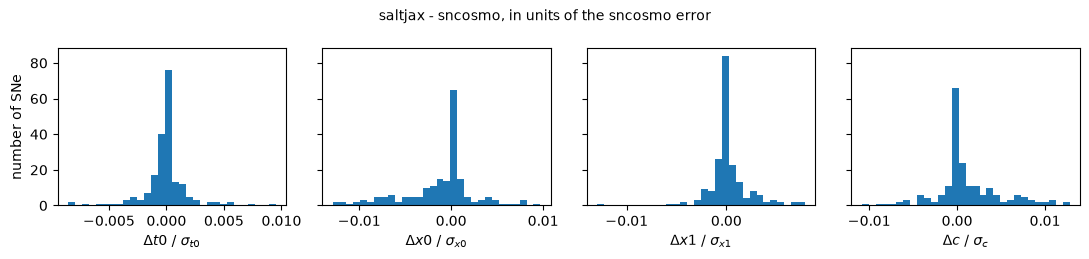

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.6), sharey=True)
for ax, p in zip(axes, PARAMS):
    ax.hist(pulls[p], bins=30, color="C0")
    ax.set_xlabel(f"$\\Delta {p}$ / $\\sigma_{{{p}}}$")
    ax.locator_params(axis="x", nbins=4)
axes[0].set_ylabel("number of SNe")
fig.suptitle("saltjax - sncosmo, in units of the sncosmo error", fontsize="medium")
fig.tight_layout()

:::{note}
The simulated lightcurves stay within the SALT2 phase range. With points beyond the model
edges (phase above +50 days for SALT2), the model drops to zero, the chi2 is no longer smooth
in t0 and the two minimizers can end up in different minima: cut such points
(e.g. with `phase_range` and a preliminary t0) in both cases.
:::

## Translation table

How the arguments of `sncosmo.fit_lc(data, model, vparam_names, ...)` translate to
{func}`saltjax.fit_salt`:

| `sncosmo.fit_lc` | `saltjax.fit_salt` |
|---|---|
| `data` (one astropy Table) | `data`: one DataFrame for all targets, MultiIndex `(target, obs)`; time column `time`, `mjd` or `jd` (or `time_key=`) |
| `model.set(z=...)` | `targets["z"]` (one row per target) |
| `model = sncosmo.Model(source="salt2")` | `source="salt2"` (name or `sncosmo.SALT2Source`), `version=` |
| `CCM89Dust` effect, `effect_frames=["obs"]`, `model.set(mwebv=...)` | `targets["mwebv"]` (column name: `mwebv_key=`), $R_V$: `mw_r_v=3.1` |
| `vparam_names=["t0", "x0", "x1", "c"]` | always these four parameters |
| `modelcov=False` (default) | `modelcov=True` (**default is True**) |
| `phase_range=(min, max)` (relative to the fitted t0) | `phase_range=[-10, 40]` (default) relative to `targets["t0"]`, or `None` |
| `guess_t0=True`, `guess_amplitude=True` | `guess="data"`: x1 = 0 and best (t0, c) on a grid around the highest S/N point, x0 solved linearly |
| start from the model parameters (`guess_*=False`) | `guess="truth"`: start from `targets["t0"]`, `["x1"]`, `["c"]` |
| `minsnr=5.` (points used for the initial guess) | `minsnr=5.`: targets without any point with S/N $\geq$ `minsnr` are skipped (with a warning), not fitted |
| `method="minuit"`, `maxcall=` | Levenberg-Marquardt in JAX, errors from the exact Hessian (as Minuit HESSE); `nrefit=10` refits at most with the model covariance |
| `zpsys` column | `zpsys` column, `"ab"` only |
| `verbose=` | `verbose=`, `progress_bar=` |
| loop over SNe | one call; `indexes=` to fit a subset of targets |

Not supported (by design, saltjax is a SALT2 fitter):

- `bounds`: parameters are not bounded (not even t0, which sncosmo bounds by default to the
  data time range).
- Fitting `z` (`guess_z`): the redshift is fixed to `targets["z"]`.
- Fixing a parameter: `t0`, `x0`, `x1` and `c` are always fitted.
- Sources other than `sncosmo.SALT2Source` (e.g. SALT3): `NotImplementedError`.
- Effects other than Milky Way CCM89 dust in the observer frame (e.g. host dust).
- Magnitude systems other than AB: `NotImplementedError`.
- `spectra` and `wave_range`.
- Bands outside the model wavelength range are **not** dropped (sncosmo drops them, with
  `warn=True` a warning): remove them from `data` yourself.

## Getting the sncosmo-like result back

The output of {func}`saltjax.fit_salt` is a DataFrame with one row per target: the parameters
`t0`, `x0`, `x1`, `c`, their errors `{p}_err`, the full covariance as `cov_{p}{q}` columns,
and `chi2`, `ndof`, `converged`, `nrefit`.

In [15]:
saltjax_results[PARAMS + [f"{p}_err" for p in PARAMS] + ["chi2", "ndof", "converged"]].head()

,t0,x0,x1,c,t0_err,x0_err,x1_err,c_err,chi2,ndof,converged
target,,,,,,,,,,,
0,58131.7,0.000463035,0.818034,0.0954778,0.237042,1.96136e-05,0.269322,0.0347737,46.4533,53,True
1,58278,0.00131506,0.224257,0.13939,0.148744,4.61286e-05,0.18152,0.0289444,24.785,44,True
2,58106.6,0.000437164,1.07766,-0.0436778,0.453746,2.66369e-05,0.533831,0.0504626,40.395,44,True
3,58290.8,0.000358449,0.269943,-0.0706765,0.469358,2.27081e-05,0.526812,0.0528045,42.7206,47,True
4,58250,0.000951723,-1.61217,0.0363394,0.154803,3.60723e-05,0.178148,0.0317962,29.6436,44,True


The `cov_{p}{q}` columns reshape into the 4x4 covariance matrix, in the order
`t0, x0, x1, c` (as `res.covariance` with `vparam_names=["t0", "x0", "x1", "c"]`):

In [16]:
def get_covariance(results, target):
    # 4x4 covariance (t0, x0, x1, c) of one target
    return results.loc[target, [f"cov_{p}{q}" for p in PARAMS for q in PARAMS]
                       ].to_numpy(float).reshape(4, 4)

cov = get_covariance(result, 0)     # the example lightcurve fitted above
sigma = np.sqrt(np.diag(res.covariance))
print("max |cov_saltjax - cov_sncosmo| / (sigma_p sigma_q) =",
      f"{(np.abs(cov - res.covariance) / np.outer(sigma, sigma)).max():.1e}")

max |cov_saltjax - cov_sncosmo| / (sigma_p sigma_q) = 6.6e-04


To plot a fit, or to evaluate the model anywhere, build an `sncosmo.Model` with the fitted
parameters:

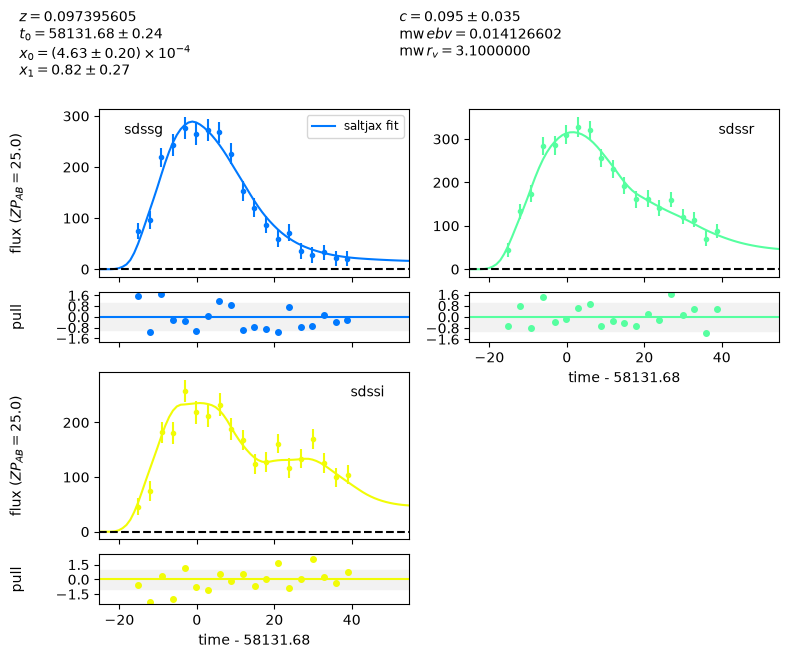

In [17]:
def to_sncosmo_model(results, target, source="salt2"):
    # sncosmo.Model with the saltjax best-fit parameters of one target
    row = results.loc[target]
    model = sncosmo.Model(source=source, effects=[sncosmo.CCM89Dust()],
                          effect_names=["mw"], effect_frames=["obs"])
    model.set(z=row["z"], t0=row["t0"], x0=row["x0"], x1=row["x1"], c=row["c"],
              mwebv=row.get("mwebv", 0.))
    return model

target = 0
fit_model = to_sncosmo_model(saltjax_results, target)
errors = {p: saltjax_results.loc[target, f"{p}_err"] for p in PARAMS}
fig = sncosmo.plot_lc(lcs[target], model=fit_model, errors=errors,
                      model_label="saltjax fit", xfigsize=8)

## Next steps

- [Quickstart](../quickstart.ipynb): the saltjax basics.
- [Validation](../examples/validation.ipynb): saltjax against sncosmo on large samples.
- [Speed](../examples/speed.ipynb): how the fit time scales with the number of lightcurves.
- [API reference](../api/index.rst): all the options of {func}`saltjax.fit_salt`.